# 01. 송도 전체 궤적의 관측 경로 정리

**이번 단계는 M1·M2의 상충 분석에 필요한 입력을 준비하는 단계입니다.** 제공된 차량 궤적을 시간순으로 정리하고, 원자료의 `Road_Section`·`Lane_Number`가 어떤 순서로 관측되었는지 기록합니다. 새 수식·상충 기준을 만드는 작업이 아닙니다.

- 대상: **20개 지점 × 4일 × AM/PM 각 5개 세션 = 전체 800개 CSV**. 일부 파일만 분석하는 기본 옵션은 없습니다.
- 산출물: 파일별 차량 궤적 요약, 관측 라벨 구간, 품질 기록, 전체 처리 현황, 관측 경로별 궤적 수.
- `Vehicle_ID`는 CSV 안에서만 고유합니다. 분석 식별자는 **원본 파일 경로 + Vehicle_ID**이며, 실제 차량의 중복 없는 대수가 아닙니다.
- 여기서 **라벨 구간(run)**은 *시간순 정렬 후 같은 구역·차로 라벨이 이어진 관측행 묶음*입니다. 끊김 없는 주행 구간·상충 사건·회전 방향을 뜻하지 않습니다.
- 라벨이 없는 행도 `<unlabeled>`로 기록합니다. 임의 보간·평활·삭제·차로 재배정은 하지 않습니다.
- TTC·PET, 속도벡터, 좌회전·우회전·직진 판정, 상충 사건 분리, EVT는 다음 단계입니다. **출력되는 수는 상충 건수가 아닙니다.**

원자료는 읽기만 하며 새 결과는 `data/processed/songdo_movement/<실행ID>/`에 저장합니다. 사용자가 위에서 아래로 셀을 실행합니다. 이 노트북에는 실제 송도 분석 실행 결과가 들어 있지 않습니다.

| 코드 셀 | 하는 일 | 확인할 점 |
|---|---|---|
| 1–3 | 환경·경로·전체 입력 목록 확인 | 800개의 날짜·지점·세션 조합 |
| 4–5 | 집계·저장 함수 정의 | 아직 실제 분석하지 않음 |
| 6 | 이번 실행의 결과 폴더 생성 | 새 실행 ID |
| 7 | **전체 800개 순차 처리** | 파일 기준 진행률·오류 |
| 8 | 전체 처리 결과 확인 | 완료 수·품질 상태 |
| 9–11 | 결과에서 차량 하나를 골라 지도 확인 | 제공 라벨·좌표의 의미 확인 |
| 12 | 다음 논의를 위한 결과 출력 | 분석 범위·미완료·판단 유보 |

자료 정의: [Songdo 공식 배포](https://zenodo.org/records/17924857), `data/raw/README.md`; Fonod et al. (2025), DOI: [10.1016/j.trc.2025.105205](https://doi.org/10.1016/j.trc.2025.105205).
방법론 기준: M1 DOI [10.1016/j.trc.2019.04.015](https://doi.org/10.1016/j.trc.2019.04.015), M2 DOI [10.1016/j.aap.2018.12.007](https://doi.org/10.1016/j.aap.2018.12.007). **M1·M2가 아래 라벨 집계 코드를 제시했다는 뜻은 아닙니다.** 아래는 제공 자료의 명목 라벨을 기록하는 입력 정리입니다.


## 1. 현재 커널의 준비 상태
필요 패키지는 pandas·numpy·Pillow·IPython입니다. 설치되지 않은 경우 셀이 필요한 이름을 알려줍니다. 그 경우 **현재 노트북 커널에서** 안내된 `%pip install ...`을 직접 실행한 뒤 이 셀부터 다시 실행하세요. 자동 설치는 하지 않습니다.


In [2]:
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import importlib.util
import json
import re
import time
import uuid

packages = {"pandas": "pandas", "numpy": "numpy", "PIL": "Pillow", "IPython": "IPython"}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    raise ImportError("현재 커널에 패키지가 없습니다. 별도 셀에서 직접 실행: %pip install "
                      + " ".join(missing))

import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

print("준비 완료 | pandas", pd.__version__, "| numpy", np.__version__)


준비 완료 | pandas 3.0.5 | numpy 2.4.6


## 2. 원자료와 결과 경로
프로젝트 폴더 또는 그 안의 `analysis` 폴더에서 실행할 수 있습니다. 경로를 찾지 못하면 노트북 작업 폴더를 이 프로젝트로 맞춥니다. 원본 데이터 경로를 변경하거나 원본 파일에 덮어쓰지 않습니다.


In [3]:
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT = next((p for p in candidates
                if (p / "AGENTS.md").is_file() and (p / "data" / "raw").is_dir()), None)
if PROJECT is None:
    raise FileNotFoundError("이 프로젝트 또는 analysis 폴더를 작업 폴더로 사용하세요.")

RAW = (PROJECT / "data" / "raw").resolve()
PROCESSED = (PROJECT / "data" / "processed" / "songdo_movement").resolve()
if not PROCESSED.is_relative_to(PROJECT) or PROCESSED.is_relative_to(RAW):
    raise ValueError("결과 경로가 프로젝트 내부이며 원자료 외부인지 확인하세요.")

SITES = list("ABCEFGHIJKLMNOPQRSTU")  # D는 Drone을 나타내므로 지점 목록에서 제외
DATES = [f"2022-10-{day:02d}" for day in range(4, 8)]
SESSIONS = [f"{period}{number}" for period in ("AM", "PM") for number in range(1, 6)]
SOURCE_COLUMNS = [
    "Vehicle_ID", "Local_Time", "Drone_ID", "Ortho_X", "Ortho_Y",
    "Local_X", "Local_Y", "Road_Section", "Lane_Number",
]
STRING_DTYPES = {name: "string" for name in
                 ["Vehicle_ID", "Local_Time", "Drone_ID", "Road_Section", "Lane_Number"]}
UNLABELED = "<unlabeled>"
print("프로젝트:", PROJECT)
print("원자료:", RAW)
print("결과 상위 폴더:", PROCESSED)


프로젝트: C:\Users\123\Documents\(송도) 교통 연구 논문
원자료: C:\Users\123\Documents\(송도) 교통 연구 논문\data\raw
결과 상위 폴더: C:\Users\123\Documents\(송도) 교통 연구 논문\data\processed\songdo_movement


## 3. 전체 입력 명세 확인 — 분석은 아직 시작하지 않음
파일명과 폴더명에서 날짜·지점·세션을 확인합니다. 단순히 800개인지 세는 데 그치지 않고 **기대하는 800개 조합과 정확히 일치하는지** 검사합니다. CSV 본문은 여기서 읽지 않습니다.

파일 크기와 수정 시각은 실행 중 파일이 달라졌는지 확인하는 보조 기록입니다. 원본 배포와의 체크섬 대조를 대신하지 않습니다.


In [4]:
expected = {
    f"{date}_{site}_{session}.csv": (date, site, session)
    for date in DATES for site in SITES for session in SESSIONS
}
found_paths = []
for folder in sorted(RAW.iterdir()):
    if folder.is_dir() and re.fullmatch(r"\d{4}-\d{2}-\d{2}_[A-Z]", folder.name):
        found_paths.extend(sorted(folder.glob("*.csv")))

found_names = [path.name for path in found_paths]
duplicates = [name for name, count in Counter(found_names).items() if count > 1]
missing_names = sorted(set(expected) - set(found_names))
unexpected_names = sorted(set(found_names) - set(expected))
misplaced = [str(path.relative_to(RAW)) for path in found_paths
             if path.name in expected
             and path.parent.name != f"{expected[path.name][0]}_{expected[path.name][1]}"]
if duplicates or missing_names or unexpected_names or misplaced:
    raise ValueError(json.dumps({
        "중복파일명": duplicates, "없는조합": missing_names,
        "예상밖파일": unexpected_names, "다른폴더에있는파일": misplaced,
    }, ensure_ascii=False, indent=2))

manifest_rows = []
for path in sorted(found_paths):
    date, site, session = expected[path.name]
    stat = path.stat()
    manifest_rows.append({
        "source_file": path.relative_to(PROJECT).as_posix(),
        "file_stem": path.stem, "date": date, "site": site, "session": session,
        "size_bytes": stat.st_size, "mtime_ns": stat.st_mtime_ns,
    })
manifest = pd.DataFrame(manifest_rows)
assert len(manifest) == len(SITES) * len(DATES) * len(SESSIONS) == 800
print(f"전체 입력 확인: {len(manifest)}개 | {len(SITES)}개 지점 × {len(DATES)}일 × {len(SESSIONS)}개 세션")
print(f"CSV 총 크기: {manifest['size_bytes'].sum() / 1e9:.2f} GB (10진)")
display(manifest.head(10))
display(manifest.groupby(["date", "site"], sort=True).size().unstack("date"))


전체 입력 확인: 800개 | 20개 지점 × 4일 × 10개 세션
CSV 총 크기: 80.02 GB (10진)


,source_file,file_stem,date,site,session,size_bytes,mtime_ns
0,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04_A_AM1,2022-10-04,A,AM1,49658094,1738673786000000000
1,data/raw/2022-10-04_A/2022-10-04_A_AM2.csv,2022-10-04_A_AM2,2022-10-04,A,AM2,94915848,1738673854000000000
2,data/raw/2022-10-04_A/2022-10-04_A_AM3.csv,2022-10-04_A_AM3,2022-10-04,A,AM3,114466338,1738673820000000000
3,data/raw/2022-10-04_A/2022-10-04_A_AM4.csv,2022-10-04_A_AM4,2022-10-04,A,AM4,76220539,1738674082000000000
4,data/raw/2022-10-04_A/2022-10-04_A_AM5.csv,2022-10-04_A_AM5,2022-10-04,A,AM5,74619764,1738674030000000000
5,data/raw/2022-10-04_A/2022-10-04_A_PM1.csv,2022-10-04_A_PM1,2022-10-04,A,PM1,85233702,1738673892000000000
6,data/raw/2022-10-04_A/2022-10-04_A_PM2.csv,2022-10-04_A_PM2,2022-10-04,A,PM2,77828942,1738673768000000000
7,data/raw/2022-10-04_A/2022-10-04_A_PM3.csv,2022-10-04_A_PM3,2022-10-04,A,PM3,85188835,1738673936000000000
8,data/raw/2022-10-04_A/2022-10-04_A_PM4.csv,2022-10-04_A_PM4,2022-10-04,A,PM4,104804357,1738673748000000000
9,data/raw/2022-10-04_A/2022-10-04_A_PM5.csv,2022-10-04_A_PM5,2022-10-04,A,PM5,72496307,1738673968000000000


date,2022-10-04,2022-10-05,2022-10-06,2022-10-07
site,,,,
A,10,10,10,10
B,10,10,10,10
C,10,10,10,10
E,10,10,10,10
F,10,10,10,10
G,10,10,10,10
H,10,10,10,10
I,10,10,10,10
J,10,10,10,10


## 4. 차량별 관측 경로를 만드는 함수
이 셀은 함수를 정의합니다. 실제 전체 자료 처리는 7번 코드 셀에서 시작합니다.

처리 원칙:
- 시간은 날짜가 아닌 `hh:mm:ss[.소수]` 형식의 하루 중 시각입니다. 날짜는 파일명 메타데이터로 별도 보존합니다.
- 같은 차량의 시각이 같으면 **원본 데이터 행 순번**으로 정렬합니다. 중복 시각을 임의 삭제하지 않습니다.
- 유효한 양의 정수 Vehicle_ID가 없는 행은 차량을 임의로 만들어 묶지 않습니다. 별도 품질 CSV에 남깁니다.
- 해석할 수 없는 시각은 경로 순서에 임의 배치하지 않습니다. 해당 차량의 제외 행 수와 품질 CSV에 기록합니다.
- 좌표가 잘못된 행도 라벨이 관측되었다는 사실은 남깁니다. 좌표가 필요한 지도 표시·시작/끝 위치 계산에서만 제외합니다.
- **라벨 누락은 품질 불량이라고 단정하지 않습니다.** 미지정 구역 등 원자료 구조의 일부일 수 있습니다.
- 관측 시각 범위·인접 관측행의 최대 시간 차이는 연속성 해석을 막기 위한 보조 기록입니다. 촬영 시간이나 누락 프레임 수로 해석하지 않습니다.


In [5]:
def prepare_rows(frame):
    """원본 행 번호와 품질 표지를 추가한다. 원본 파일은 수정하지 않는다."""
    work = frame.copy()
    if "_source_row" not in work:
        work["_source_row"] = np.arange(1, len(work) + 1, dtype=np.int64)
    for column in STRING_DTYPES:
        work[column] = work[column].astype("string")
    work["_valid_id"] = work["Vehicle_ID"].str.fullmatch(r"[1-9]\d*", na=False)
    valid_clock = work["Local_Time"].str.fullmatch(
        r"(?:[01]\d|2[0-3]):[0-5]\d:[0-5]\d(?:\.\d{1,9})?", na=False
    )
    work["_time"] = pd.to_timedelta(work["Local_Time"].where(valid_clock), errors="coerce")
    work["_valid_time"] = work["_time"].notna()
    for column in ["Local_X", "Local_Y", "Ortho_X", "Ortho_Y"]:
        work[column] = pd.to_numeric(work[column], errors="coerce").astype("float64")
    work["_valid_local"] = np.isfinite(work[["Local_X", "Local_Y"]]).all(axis=1)
    work["_valid_ortho"] = np.isfinite(work[["Ortho_X", "Ortho_Y"]]).all(axis=1)
    for column, name in [("Road_Section", "section"), ("Lane_Number", "lane")]:
        blank = work[column].isna() | work[column].str.fullmatch(r"\s*", na=False)
        work[f"_missing_{name}"] = blank
        work[f"_{name}_label"] = work[column].mask(blank, UNLABELED)
    return work


def summarize_file(frame, item):
    """한 파일 안의 차량별 요약·관측 라벨 구간·품질 행을 반환한다."""
    work = prepare_rows(frame)
    issue_mask = ~work[["_valid_id", "_valid_time", "_valid_local", "_valid_ortho"]].all(axis=1)
    issue_columns = SOURCE_COLUMNS + [
        "_source_row", "_valid_id", "_valid_time", "_valid_local", "_valid_ortho",
    ]
    quality_rows = work.loc[issue_mask, issue_columns].copy()
    quality_rows.insert(0, "source_file", item["source_file"])
    quality_rows = quality_rows.rename(columns={"_source_row": "source_data_row"})
    quality_rows["issue"] = ""
    for flag, label in [
        ("_valid_id", "invalid_vehicle_id"), ("_valid_time", "invalid_time"),
        ("_valid_local", "invalid_local_xy"), ("_valid_ortho", "invalid_ortho_xy"),
    ]:
        quality_rows["issue"] += np.where(~quality_rows[flag], label + ";", "")
    quality_rows["issue"] = quality_rows["issue"].str.rstrip(";")

    # 식별 가능한 모든 차량을 요약에 남긴다. 시각 오류만으로 차량 전체를 없애지 않는다.
    identified = work.loc[work["_valid_id"]].copy()
    stats = identified.groupby("Vehicle_ID", sort=True).agg(
        n_rows=("_source_row", "size"),
        n_valid_time_rows=("_valid_time", "sum"),
        n_valid_local_rows=("_valid_local", "sum"),
        n_valid_ortho_rows=("_valid_ortho", "sum"),
        n_missing_section_rows=("_missing_section", "sum"),
        n_missing_lane_rows=("_missing_lane", "sum"),
    )
    for short in ["time", "local", "ortho"]:
        stats[f"n_invalid_{short}_rows"] = stats["n_rows"] - stats[f"n_valid_{short}_rows"]
    drone_ids = identified.groupby("Vehicle_ID", sort=False)["Drone_ID"].agg(
        lambda values: json.dumps(sorted(values.dropna().unique().tolist()), ensure_ascii=False)
    )
    stats["drone_ids_json"] = drone_ids

    ordered = identified.loc[identified["_valid_time"]].sort_values(
        ["Vehicle_ID", "_time", "_source_row"], kind="stable"
    ).copy()
    ordered["_gap_s"] = ordered.groupby("Vehicle_ID", sort=False)["_time"].diff().dt.total_seconds()
    duplicate_mask = ordered.duplicated(["Vehicle_ID", "_time"], keep=False)
    duplicate_counts = duplicate_mask.groupby(ordered["Vehicle_ID"], sort=False).sum()
    stats["n_rows_at_duplicate_times"] = duplicate_counts.reindex(stats.index, fill_value=0)
    time_group = ordered.groupby("Vehicle_ID", sort=False)
    times = time_group.agg(
        first_valid_time=("Local_Time", "first"),
        last_valid_time=("Local_Time", "last"),
        first_valid_time_source_row=("_source_row", "first"),
        last_valid_time_source_row=("_source_row", "last"),
        min_time=("_time", "min"), max_time=("_time", "max"),
        max_adjacent_observed_time_gap_s=("_gap_s", "max"),
    )
    times["observed_time_span_s"] = (times.pop("max_time") - times.pop("min_time")).dt.total_seconds()
    stats = stats.join(times)

    valid_positions = ordered.loc[ordered["_valid_local"]]
    for which, rows in [
        ("first", valid_positions.groupby("Vehicle_ID", sort=False).head(1)),
        ("last", valid_positions.groupby("Vehicle_ID", sort=False).tail(1)),
    ]:
        position = rows.set_index("Vehicle_ID")[["Local_Time", "Local_X", "Local_Y", "_source_row"]]
        position = position.rename(columns={
            "Local_Time": f"{which}_valid_local_time",
            "Local_X": f"{which}_valid_local_x_m", "Local_Y": f"{which}_valid_local_y_m",
            "_source_row": f"{which}_valid_local_source_row",
        })
        stats = stats.join(position)

    new_run = (
        ordered["Vehicle_ID"].ne(ordered["Vehicle_ID"].shift()).fillna(True)
        | ordered["_section_label"].ne(ordered["_section_label"].shift()).fillna(True)
        | ordered["_lane_label"].ne(ordered["_lane_label"].shift()).fillna(True)
    )
    ordered["_run_global"] = new_run.astype("int64").cumsum()
    ordered["_within_run_gap_s"] = ordered["_gap_s"].where(~new_run)
    runs = ordered.groupby("_run_global", sort=False).agg(
        Vehicle_ID=("Vehicle_ID", "first"),
        road_section=("_section_label", "first"), lane_number=("_lane_label", "first"),
        section_unlabeled=("_missing_section", "first"), lane_unlabeled=("_missing_lane", "first"),
        n_rows=("_source_row", "size"),
        first_time=("Local_Time", "first"), last_time=("Local_Time", "last"),
        first_source_data_row=("_source_row", "first"), last_source_data_row=("_source_row", "last"),
        first_elapsed=("_time", "first"), last_elapsed=("_time", "last"),
        max_within_run_observed_time_gap_s=("_within_run_gap_s", "max"),
    ).reset_index(drop=True)
    runs["run_number"] = runs.groupby("Vehicle_ID", sort=False).cumcount() + 1
    runs["observed_time_span_s"] = (runs.pop("last_elapsed") - runs.pop("first_elapsed")).dt.total_seconds()
    runs["max_within_run_observed_time_gap_s"] = runs["max_within_run_observed_time_gap_s"].fillna(0.0)
    runs["label_pair_json"] = [
        json.dumps([section, lane], ensure_ascii=False)
        for section, lane in zip(runs["road_section"], runs["lane_number"])
    ]
    sequences = runs.groupby("Vehicle_ID", sort=False)["label_pair_json"].agg(
        lambda values: "[" + ",".join(values) + "]"
    )
    stats["observed_label_sequence_json"] = sequences.reindex(stats.index).fillna("[]")
    stats["n_label_runs"] = runs.groupby("Vehicle_ID").size().reindex(stats.index, fill_value=0)
    stats["quality_status"] = ""
    for column, label in [
        ("n_invalid_time_rows", "invalid_time"),
        ("n_invalid_local_rows", "invalid_local_xy"),
        ("n_invalid_ortho_rows", "invalid_ortho_xy"),
        ("n_rows_at_duplicate_times", "duplicate_time"),
    ]:
        stats["quality_status"] += np.where(stats[column] > 0, label + ";", "")
    stats["quality_status"] = stats["quality_status"].str.rstrip(";").replace("", "no_flag_in_checked_fields")
    stats["label_order_status"] = np.select(
        [stats["n_valid_time_rows"].eq(0), stats["n_invalid_time_rows"].gt(0)],
        ["unavailable_no_valid_time", "partial_invalid_time_rows_excluded"],
        default="all_identified_rows_time_ordered",
    )
    summary = stats.reset_index()
    for table in [summary, runs]:
        table.insert(0, "actor_id", item["source_file"] + "::" + table["Vehicle_ID"].astype(str))
        for column in ["session", "site", "date", "source_file"]:
            table.insert(0, column, item[column])

    counts = {
        "n_source_rows": int(len(work)), "n_trajectories": int(len(summary)),
        "n_label_runs": int(len(runs)), "n_quality_rows": int(len(quality_rows)),
        "n_invalid_id_rows": int((~work["_valid_id"]).sum()),
        "n_invalid_time_rows": int((~work["_valid_time"]).sum()),
        "n_invalid_local_rows": int((~work["_valid_local"]).sum()),
        "n_invalid_ortho_rows": int((~work["_valid_ortho"]).sum()),
        "n_missing_section_rows": int(work["_missing_section"].sum()),
        "n_missing_lane_rows": int(work["_missing_lane"].sum()),
        "n_rows_at_duplicate_times": int(duplicate_mask.sum()),
        "n_trajectories_without_valid_time": int(summary["n_valid_time_rows"].eq(0).sum()),
    }
    return summary, runs, quality_rows, counts

print("경로 요약 함수 정의 완료. 아직 원자료 본문을 분석하지 않았습니다.")


경로 요약 함수 정의 완료. 아직 원자료 본문을 분석하지 않았습니다.


## 5. 결과 저장 함수
저장 위치가 **이번 실행 폴더 내부이며 원자료 외부**인지 검사합니다. 저장 도중 중단되어도 이미 완료된 다른 파일의 결과는 남습니다. CSV의 `source_data_row`는 **헤더 다음 첫 데이터 행이 1**인 논리적 행 번호입니다.


In [6]:
def checked_output(path):
    target = Path(path).resolve()
    if not target.is_relative_to(RUN_DIR.resolve()) or target.is_relative_to(RAW):
        raise ValueError("허용된 이번 실행의 결과 경로가 아닙니다: " + str(target))
    return target


def save_json(value, path):
    target = checked_output(path)
    temporary = target.with_name(target.name + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding="utf-8")
    temporary.replace(target)


def save_csv(table, path):
    target = checked_output(path)
    temporary = target.with_name(target.name + ".tmp")
    table.to_csv(temporary, index=False, encoding="utf-8-sig")
    temporary.replace(target)


def timestamp_now():
    return datetime.now(timezone.utc).isoformat()


def input_stat_unchanged(item):
    stat = (PROJECT / item["source_file"]).stat()
    return stat.st_size == item["size_bytes"] and stat.st_mtime_ns == item["mtime_ns"]


def sequence_table(counter):
    return pd.DataFrame([
        {"site": site, "observed_label_sequence_json": sequence, "n_trajectories": int(count)}
        for (site, sequence), count in counter.items()
    ], columns=["site", "observed_label_sequence_json", "n_trajectories"]).sort_values(
        ["site", "n_trajectories", "observed_label_sequence_json"], ascending=[True, False, True]
    )

print("저장 함수 정의 완료.")


저장 함수 정의 완료.


## 6. 이번 실행의 결과 폴더 만들기
이 셀을 다시 실행하면 **새 실행 폴더**가 생깁니다. 기존 실행 결과를 자동으로 이어 쓰거나 재사용하지 않습니다.

전체 원본은 약 80GB이므로 디스크·메모리·커널에 따라 시간이 걸립니다. 실행 시간은 아직 측정하지 않았습니다. 한 파일씩 필요한 열만 읽고, 처리한 원시 표는 다음 파일 전에 해제합니다.


In [7]:
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
RUN_DIR = (PROCESSED / RUN_ID).resolve()
if not RUN_DIR.is_relative_to(PROJECT) or RUN_DIR.is_relative_to(RAW):
    raise ValueError("결과 폴더 경로 검증 실패")
RUN_DIR.mkdir(parents=True, exist_ok=False)
for subfolder in ["trajectories", "label_runs", "quality"]:
    (RUN_DIR / subfolder).mkdir()

run_metadata = {
    "run_id": RUN_ID, "started_at_utc": timestamp_now(), "finished_at_utc": None,
    "status": "ready", "expected_files": len(manifest), "attempted_files": 0,
    "completed_files": 0, "failed_files": 0,
    "source_columns": SOURCE_COLUMNS,
    "scope": "all_800_songdo_csv_observed_label_order_only",
    "original_files_are_read_only": True,
    "label_run_definition": "same provided labels in time-sorted observed rows; not a continuous driving episode",
    "invalid_id_policy": "keep in quality CSV; do not invent vehicle identity",
    "invalid_time_policy": "keep in quality CSV and counts; exclude from temporal label sequence",
    "coordinates": "Local_X/Y EPSG:5186 meters; Ortho_X/Y 8000px image centers",
    "source_data_row_definition": "1-based parsed data row; header excluded",
    "event_or_movement_classification": "not_performed",
}
save_csv(manifest, RUN_DIR / "input_manifest.csv")
save_json(run_metadata, RUN_DIR / "run_metadata.json")
print("이번 결과 폴더:", RUN_DIR)
print("다음 셀이 전체 800개 파일을 처리합니다.")


이번 결과 폴더: C:\Users\123\Documents\(송도) 교통 연구 논문\data\processed\songdo_movement\20260916T063821Z_28f9e8ee
다음 셀이 전체 800개 파일을 처리합니다.


## 7. 전체 800개 파일 순차 처리
**실제 분석이 시작되는 셀입니다.** 한 파일이 완료될 때마다 궤적 요약·라벨 구간·품질 행과 진행 기록을 저장합니다.

- 화면은 20개 파일마다 갱신하고, 오류가 나면 해당 파일명을 출력합니다.
- 파일 오류는 기록하고 나머지 파일을 계속 처리합니다. 오류 파일이 있으면 전체 완료라고 표시하지 않습니다.
- 중단하면 이번 실행은 `interrupted`로 표시되고 앞서 완료된 결과는 보존됩니다. 재실행하려면 6번 셀부터 새 실행을 만듭니다.
- 원본 파일의 크기·수정 시각이 입력 명세와 달라지면 그 파일은 오류로 기록합니다.


In [8]:
if run_metadata["status"] != "ready":
    raise RuntimeError("이 실행은 이미 시작되었습니다. 다시 실행하려면 6번 셀에서 새 실행 폴더를 만드세요.")

progress_rows = []
started_monotonic = time.perf_counter()
run_metadata["status"] = "running"
save_json(run_metadata, RUN_DIR / "run_metadata.json")

try:
    for index, item in enumerate(manifest.to_dict("records"), start=1):
        file_started = time.perf_counter()
        record = {key: item[key] for key in ["source_file", "file_stem", "date", "site", "session"]}
        frame = summary = runs = quality_rows = None
        try:
            if not input_stat_unchanged(item):
                raise RuntimeError("분석 시작 전 원본 파일 크기 또는 수정 시각이 변경됨")
            frame = pd.read_csv(
                PROJECT / item["source_file"], usecols=SOURCE_COLUMNS,
                dtype=STRING_DTYPES, keep_default_na=False, na_values=[""],
                low_memory=False,
            )
            summary, runs, quality_rows, counts = summarize_file(frame, item)
            if not input_stat_unchanged(item):
                raise RuntimeError("분석 중 원본 파일 크기 또는 수정 시각이 변경됨")
            save_csv(summary, RUN_DIR / "trajectories" / (item["file_stem"] + "_trajectories.csv"))
            save_csv(runs, RUN_DIR / "label_runs" / (item["file_stem"] + "_label_runs.csv"))
            save_csv(quality_rows, RUN_DIR / "quality" / (item["file_stem"] + "_quality_rows.csv"))
            record.update(status="completed", error="", **counts)
        except Exception as error:
            record.update(status="failed", error=type(error).__name__ + ": " + str(error))
            print("파일 오류:", item["file_stem"], "|", record["error"][:240])
        except BaseException as error:
            record.update(status="interrupted", error=type(error).__name__)
            raise
        finally:
            record["elapsed_s"] = round(time.perf_counter() - file_started, 3)
            progress_rows.append(record)
            frame = summary = runs = quality_rows = None
            progress = pd.DataFrame(progress_rows)
            run_metadata.update(
                attempted_files=len(progress_rows),
                completed_files=int(progress["status"].eq("completed").sum()),
                failed_files=int(progress["status"].eq("failed").sum()),
                elapsed_s=round(time.perf_counter() - started_monotonic, 3),
            )
            save_csv(progress, RUN_DIR / "progress.csv")
            save_json(run_metadata, RUN_DIR / "run_metadata.json")
        if index == 1 or index % 20 == 0 or index == len(manifest):
            print(f"{index}/{len(manifest)}개 시도 | 완료 {run_metadata['completed_files']}개"
                  f" | 오류 {run_metadata['failed_files']}개"
                  f" | 경과 {run_metadata['elapsed_s'] / 60:.1f}분")
    run_metadata["status"] = (
        "completed" if run_metadata["completed_files"] == len(manifest) else "incomplete_with_errors"
    )
except BaseException as error:
    run_metadata["status"] = "interrupted"
    run_metadata["interruption"] = type(error).__name__
    raise
finally:
    run_metadata["finished_at_utc"] = timestamp_now()
    run_metadata["elapsed_s"] = round(time.perf_counter() - started_monotonic, 3)
    # Aggregate only saved summaries whose file status is completed.
    # An interrupted file never contributes even if some output files were written.
    sequence_counts = Counter()
    for finished in progress_rows:
        if finished.get("status") != "completed":
            continue
        saved_sequences = pd.read_csv(
            RUN_DIR / "trajectories" / (finished["file_stem"] + "_trajectories.csv"),
            usecols=["observed_label_sequence_json"], keep_default_na=False,
        )["observed_label_sequence_json"]
        for sequence, count in saved_sequences.value_counts().items():
            sequence_counts[(finished["site"], sequence)] += int(count)
    save_csv(sequence_table(sequence_counts), RUN_DIR / "observed_label_sequences.csv")
    save_json(run_metadata, RUN_DIR / "run_metadata.json")

print("처리 상태:", run_metadata["status"])
print("아래 수치는 모두 궤적·라벨 관측 수이며 상충 건수가 아닙니다.")


1/800개 시도 | 완료 1개 | 오류 0개 | 경과 0.0분
20/800개 시도 | 완료 20개 | 오류 0개 | 경과 1.0분
40/800개 시도 | 완료 40개 | 오류 0개 | 경과 1.4분
60/800개 시도 | 완료 60개 | 오류 0개 | 경과 1.8분
80/800개 시도 | 완료 80개 | 오류 0개 | 경과 2.6분
100/800개 시도 | 완료 100개 | 오류 0개 | 경과 4.3분
120/800개 시도 | 완료 120개 | 오류 0개 | 경과 5.9분
140/800개 시도 | 완료 140개 | 오류 0개 | 경과 6.6분
160/800개 시도 | 완료 160개 | 오류 0개 | 경과 7.3분
180/800개 시도 | 완료 180개 | 오류 0개 | 경과 8.9분
200/800개 시도 | 완료 200개 | 오류 0개 | 경과 9.6분
220/800개 시도 | 완료 220개 | 오류 0개 | 경과 10.9분
240/800개 시도 | 완료 240개 | 오류 0개 | 경과 11.5분
260/800개 시도 | 완료 260개 | 오류 0개 | 경과 11.9분
280/800개 시도 | 완료 280개 | 오류 0개 | 경과 12.9분
300/800개 시도 | 완료 300개 | 오류 0개 | 경과 14.8분
320/800개 시도 | 완료 320개 | 오류 0개 | 경과 16.5분
340/800개 시도 | 완료 340개 | 오류 0개 | 경과 17.3분
360/800개 시도 | 완료 360개 | 오류 0개 | 경과 18.0분
380/800개 시도 | 완료 380개 | 오류 0개 | 경과 19.8분
400/800개 시도 | 완료 400개 | 오류 0개 | 경과 20.6분
420/800개 시도 | 완료 420개 | 오류 0개 | 경과 21.8분
440/800개 시도 | 완료 440개 | 오류 0개 | 경과 22.5분
460/800개 시도 | 완료 460개 | 오류 0개 | 경과 22.9분
480/800개 시도 | 완료 480개 | 오류 0개 | 경과 23.8

## 8. 전체 처리 상태와 품질 집계
800개 완료 여부를 먼저 봅니다. 품질 항목들은 서로 겹칠 수 있으므로 합해서 전체 불량 행 수로 해석하지 않습니다. `quality_rows`는 확인한 ID·시각·좌표 중 하나 이상 문제가 있는 행 수입니다.

라벨 누락률은 **관측행 기준**이며, 상충 미검출률이 아닙니다. 관측 경로 빈도도 좌회전·우회전·직진 대수로 해석하지 않습니다.


In [9]:
progress = pd.read_csv(RUN_DIR / "progress.csv", keep_default_na=False)
completed = progress.loc[progress["status"].eq("completed")].copy()
count_columns = [column for column in progress if column.startswith("n_")]
for column in count_columns:
    completed[column] = pd.to_numeric(completed[column], errors="raise").astype("int64")
totals = completed[count_columns].sum()
print("실행 ID:", RUN_ID)
print(f"상태: {run_metadata['status']} | 완료 {len(completed)}/{len(manifest)}개"
      f" | 파일 오류 {progress['status'].eq('failed').sum()}개")
if len(completed) != len(manifest):
    print("주의: 아래 표는 완료된 파일에 한정됩니다. 아직 송도 전체 결과가 아닙니다.")
display(totals.rename("완료파일_합계").to_frame())
if int(totals.get("n_source_rows", 0)):
    denominator = int(totals["n_source_rows"])
    print(f"구역 라벨 누락 관측행: {100 * totals['n_missing_section_rows'] / denominator:.3f}%")
    print(f"차로 라벨 누락 관측행: {100 * totals['n_missing_lane_rows'] / denominator:.3f}%")
if len(completed):
    display(completed.groupby("site", sort=True).agg(
        completed_files=("source_file", "size"),
        trajectory_records=("n_trajectories", "sum"),
        source_rows=("n_source_rows", "sum"),
        label_runs=("n_label_runs", "sum"),
        rows_with_quality_flag=("n_quality_rows", "sum"),
    ))
if progress["status"].eq("failed").any():
    display(progress.loc[progress["status"].eq("failed"), ["source_file", "error"]].head(20))
route_counts = pd.read_csv(RUN_DIR / "observed_label_sequences.csv", keep_default_na=False)
print("많이 관측된 라벨 순서 15개 — 회전 방향을 판정한 결과가 아닙니다.")
display(route_counts.sort_values("n_trajectories", ascending=False, kind="stable").head(15))


실행 ID: 20260916T063821Z_28f9e8ee
상태: completed | 완료 800/800개 | 파일 오류 0개


,완료파일_합계
n_source_rows,776944506
n_trajectories,688840
n_label_runs,2841482
n_quality_rows,0
n_invalid_id_rows,0
n_invalid_time_rows,0
n_invalid_local_rows,0
n_invalid_ortho_rows,0
n_missing_section_rows,229854781
n_missing_lane_rows,229854781


구역 라벨 누락 관측행: 29.584%
차로 라벨 누락 관측행: 29.584%


,completed_files,trajectory_records,source_rows,label_runs,rows_with_quality_flag
site,,,,,
A,40,35349,36225897,138213,0
B,40,45721,50295372,259997,0
C,40,15867,17893284,57405,0
E,40,26301,22508706,118865,0
F,40,21524,23039005,117417,0
G,40,4799,8190575,18437,0
H,40,14578,32460368,60827,0
I,40,29070,31467980,105686,0
J,40,60493,73937939,197189,0


많이 관측된 라벨 순서 15개 — 회전 방향을 판정한 결과가 아닙니다.


,site,observed_label_sequence_json,n_trajectories
12728,J,"[[""<unlabeled>"", ""<unlabeled>""]]",6105
17658,L,"[[""<unlabeled>"", ""<unlabeled>""]]",5979
9832,H,"[[""<unlabeled>"", ""<unlabeled>""]]",5048
27576,P,"[[""<unlabeled>"", ""<unlabeled>""]]",4389
23775,N,"[[""<unlabeled>"", ""<unlabeled>""]]",3508
15234,K,"[[""<unlabeled>"", ""<unlabeled>""]]",3089
32218,S,"[[""1_4"", ""6""],[""<unlabeled>"", ""<unlabeled>""],[...",2981
28832,Q,"[[""<unlabeled>"", ""<unlabeled>""]]",2763
2043,B,"[[""<unlabeled>"", ""<unlabeled>""]]",2640
32219,S,"[[""2_4"", ""7""],[""<unlabeled>"", ""<unlabeled>""],[...",2368


## 9. 전체 결과에서 지도 확인용 차량 선택
전체 처리 결과를 만든 뒤 **한 차량의 실제 관측점과 제공 차로 구역이 어떻게 겹치는지** 확인합니다. 별도 소수 표본 예비분석이 아닙니다.

처음에는 완료된 파일 중 이름순 첫 파일과 그 파일의 첫 Vehicle_ID를 선택합니다. 확인할 파일·ID가 있으면 아래 두 변수에 직접 입력하세요. 기존 결과를 자동 재사용하지 않고 **이번 실행에서 완료된 파일만** 선택합니다.


In [10]:
SELECT_FILE = None  # 예: "2022-10-04_A_AM1" (확장자 제외); None이면 이번 완료 파일 중 첫 파일
SELECT_VEHICLE_ID = None  # 예: "1"; None이면 선택 파일의 첫 번째 식별 가능한 차량

if completed.empty:
    raise RuntimeError("완료된 파일이 없어 지도 확인을 할 수 없습니다.")
available_stems = sorted(completed["file_stem"].tolist())
selected_stem = SELECT_FILE if SELECT_FILE is not None else available_stems[0]
if selected_stem not in available_stems:
    raise ValueError("이번 실행에서 완료된 파일명을 선택하세요.")
selected_item = manifest.loc[manifest["file_stem"].eq(selected_stem)].iloc[0].to_dict()
selected_summary = pd.read_csv(
    RUN_DIR / "trajectories" / (selected_stem + "_trajectories.csv"),
    dtype={"Vehicle_ID": "string"}, keep_default_na=False,
)
if selected_summary.empty:
    raise ValueError("이 파일에는 식별 가능한 Vehicle_ID가 없습니다. 다른 완료 파일을 선택하세요.")
selected_vehicle = str(SELECT_VEHICLE_ID) if SELECT_VEHICLE_ID is not None else str(selected_summary.iloc[0]["Vehicle_ID"])
if not selected_summary["Vehicle_ID"].eq(selected_vehicle).any():
    raise ValueError("선택한 Vehicle_ID가 이 파일의 요약에 없습니다.")
print("선택:", selected_stem, "| Vehicle_ID:", selected_vehicle)
display(selected_summary.loc[selected_summary["Vehicle_ID"].eq(selected_vehicle)].T)
print("다른 차량 선택 시 아래 예시 ID를 참고하세요.")
display(selected_summary[["Vehicle_ID", "n_rows", "observed_label_sequence_json", "quality_status"]].head(10))


선택: 2022-10-04_A_AM1 | Vehicle_ID: 1


,0
source_file,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv
date,2022-10-04
site,A
session,AM1
actor_id,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1
Vehicle_ID,1
n_rows,84
n_valid_time_rows,84
n_valid_local_rows,84
n_valid_ortho_rows,84


다른 차량 선택 시 아래 예시 ID를 참고하세요.


,Vehicle_ID,n_rows,observed_label_sequence_json,quality_status
0,1,84,"[[""3_1"", ""3""],[""3_1"", ""2""],[""3_1"", ""3""],[""3_1""...",no_flag_in_checked_fields
1,10,1440,"[[""<unlabeled>"", ""<unlabeled>""]]",no_flag_in_checked_fields
2,100,415,"[[""4_2"", ""1""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
3,101,2837,"[[""3_4"", ""5""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
4,102,520,"[[""4_2"", ""3""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
5,103,391,"[[""4_2"", ""4""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
6,104,737,"[[""4_2"", ""2""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
7,105,682,"[[""4_2"", ""2""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
8,106,3981,"[[""3_4"", ""2""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields
9,107,435,"[[""4_2"", ""1""],[""<unlabeled>"", ""<unlabeled>""],[...",no_flag_in_checked_fields


## 10. 선택한 차량의 원본 관측점 읽기
선택 파일을 청크 단위로 다시 읽고 해당 Vehicle_ID의 행만 보관합니다. 전체 800개 원시 표를 메모리에 합치지 않습니다. 원본 행 순번도 유지합니다.


In [11]:
if not input_stat_unchanged(selected_item):
    raise RuntimeError("전체 처리 이후 선택한 원본 파일의 크기 또는 수정 시각이 달라졌습니다.")
selected_parts = []
offset = 0
for chunk in pd.read_csv(
    PROJECT / selected_item["source_file"], usecols=SOURCE_COLUMNS,
    dtype=STRING_DTYPES, keep_default_na=False, na_values=[""],
    low_memory=False, chunksize=250_000,
):
    mask = chunk["Vehicle_ID"].eq(selected_vehicle).fillna(False)
    selected_part = chunk.loc[mask].copy()
    selected_part["_source_row"] = np.flatnonzero(mask.to_numpy(dtype=bool)) + offset + 1
    if not selected_part.empty:
        selected_parts.append(selected_part)
    offset += len(chunk)
if not input_stat_unchanged(selected_item):
    raise RuntimeError("선택한 차량을 읽는 중 원본 파일이 달라졌습니다.")
if not selected_parts:
    raise ValueError("선택 차량의 원본 행을 찾지 못했습니다.")
selected_points = prepare_rows(pd.concat(selected_parts, ignore_index=True))
selected_points = selected_points.sort_values("_source_row", kind="stable")
selected_runs = pd.read_csv(
    RUN_DIR / "label_runs" / (selected_stem + "_label_runs.csv"),
    dtype={"Vehicle_ID": "string"}, keep_default_na=False,
)
selected_runs = selected_runs.loc[selected_runs["Vehicle_ID"].eq(selected_vehicle)]
print("선택 차량의 원본 관측행:", len(selected_points))
display(selected_runs.head(30))
print("구간이 30개를 넘으면 전체 라벨 구간 CSV에서 확인할 수 있습니다.")


선택 차량의 원본 관측행: 84


,source_file,date,site,session,actor_id,Vehicle_ID,road_section,lane_number,section_unlabeled,lane_unlabeled,n_rows,first_time,last_time,first_source_data_row,last_source_data_row,max_within_run_observed_time_gap_s,run_number,observed_time_span_s,label_pair_json
0,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,3,False,False,1,07:02:50.038,07:02:50.038,1,1,0.000,1,0.000,"[""3_1"", ""3""]"
1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,2,False,False,7,07:02:50.071,07:02:50.272,2,8,0.034,2,0.201,"[""3_1"", ""2""]"
2,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,3,False,False,1,07:02:50.305,07:02:50.305,9,9,0.000,3,0.000,"[""3_1"", ""3""]"
3,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,2,False,False,33,07:02:50.339,07:02:51.407,10,42,0.035,4,1.068,"[""3_1"", ""2""]"
4,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,3,False,False,1,07:02:51.440,07:02:51.440,43,43,0.000,5,0.000,"[""3_1"", ""3""]"
5,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,2,False,False,12,07:02:51.473,07:02:51.841,44,55,0.034,6,0.368,"[""3_1"", ""2""]"
6,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_1,3,False,False,28,07:02:51.874,07:02:52.774,56,83,0.036,7,0.900,"[""3_1"", ""3""]"
7,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv,2022-10-04,A,AM1,data/raw/2022-10-04_A/2022-10-04_A_AM1.csv::1,1,3_2,3,False,False,1,07:02:52.807,07:02:52.807,84,84,0.000,8,0.000,"[""3_2"", ""3""]"


구간이 30개를 넘으면 전체 라벨 구간 CSV에서 확인할 수 있습니다.


## 11. 정사영상에 관측점과 제공 차로 다각형 표시
지도와 `Ortho_X/Y`는 8000픽셀 기준입니다. 표시 크기에 맞게 같은 비율로 축소합니다. **관측점 사이를 선으로 잇지 않으므로 시간 공백을 연속 주행처럼 보이지 않게 합니다.**

범례: 청록색은 유효 시각의 관측점, 보라색은 시각 오류가 있는 관측점, 초록색은 시각·영상 좌표가 유효한 첫 점, 빨간색은 마지막 점입니다. 차로 다각형은 노란색입니다. **좌표를 도로에 붙이거나 라벨을 수정하지 않습니다.** 원본 영상 좌표가 지도 바깥이면 그 개수를 따로 표시합니다.


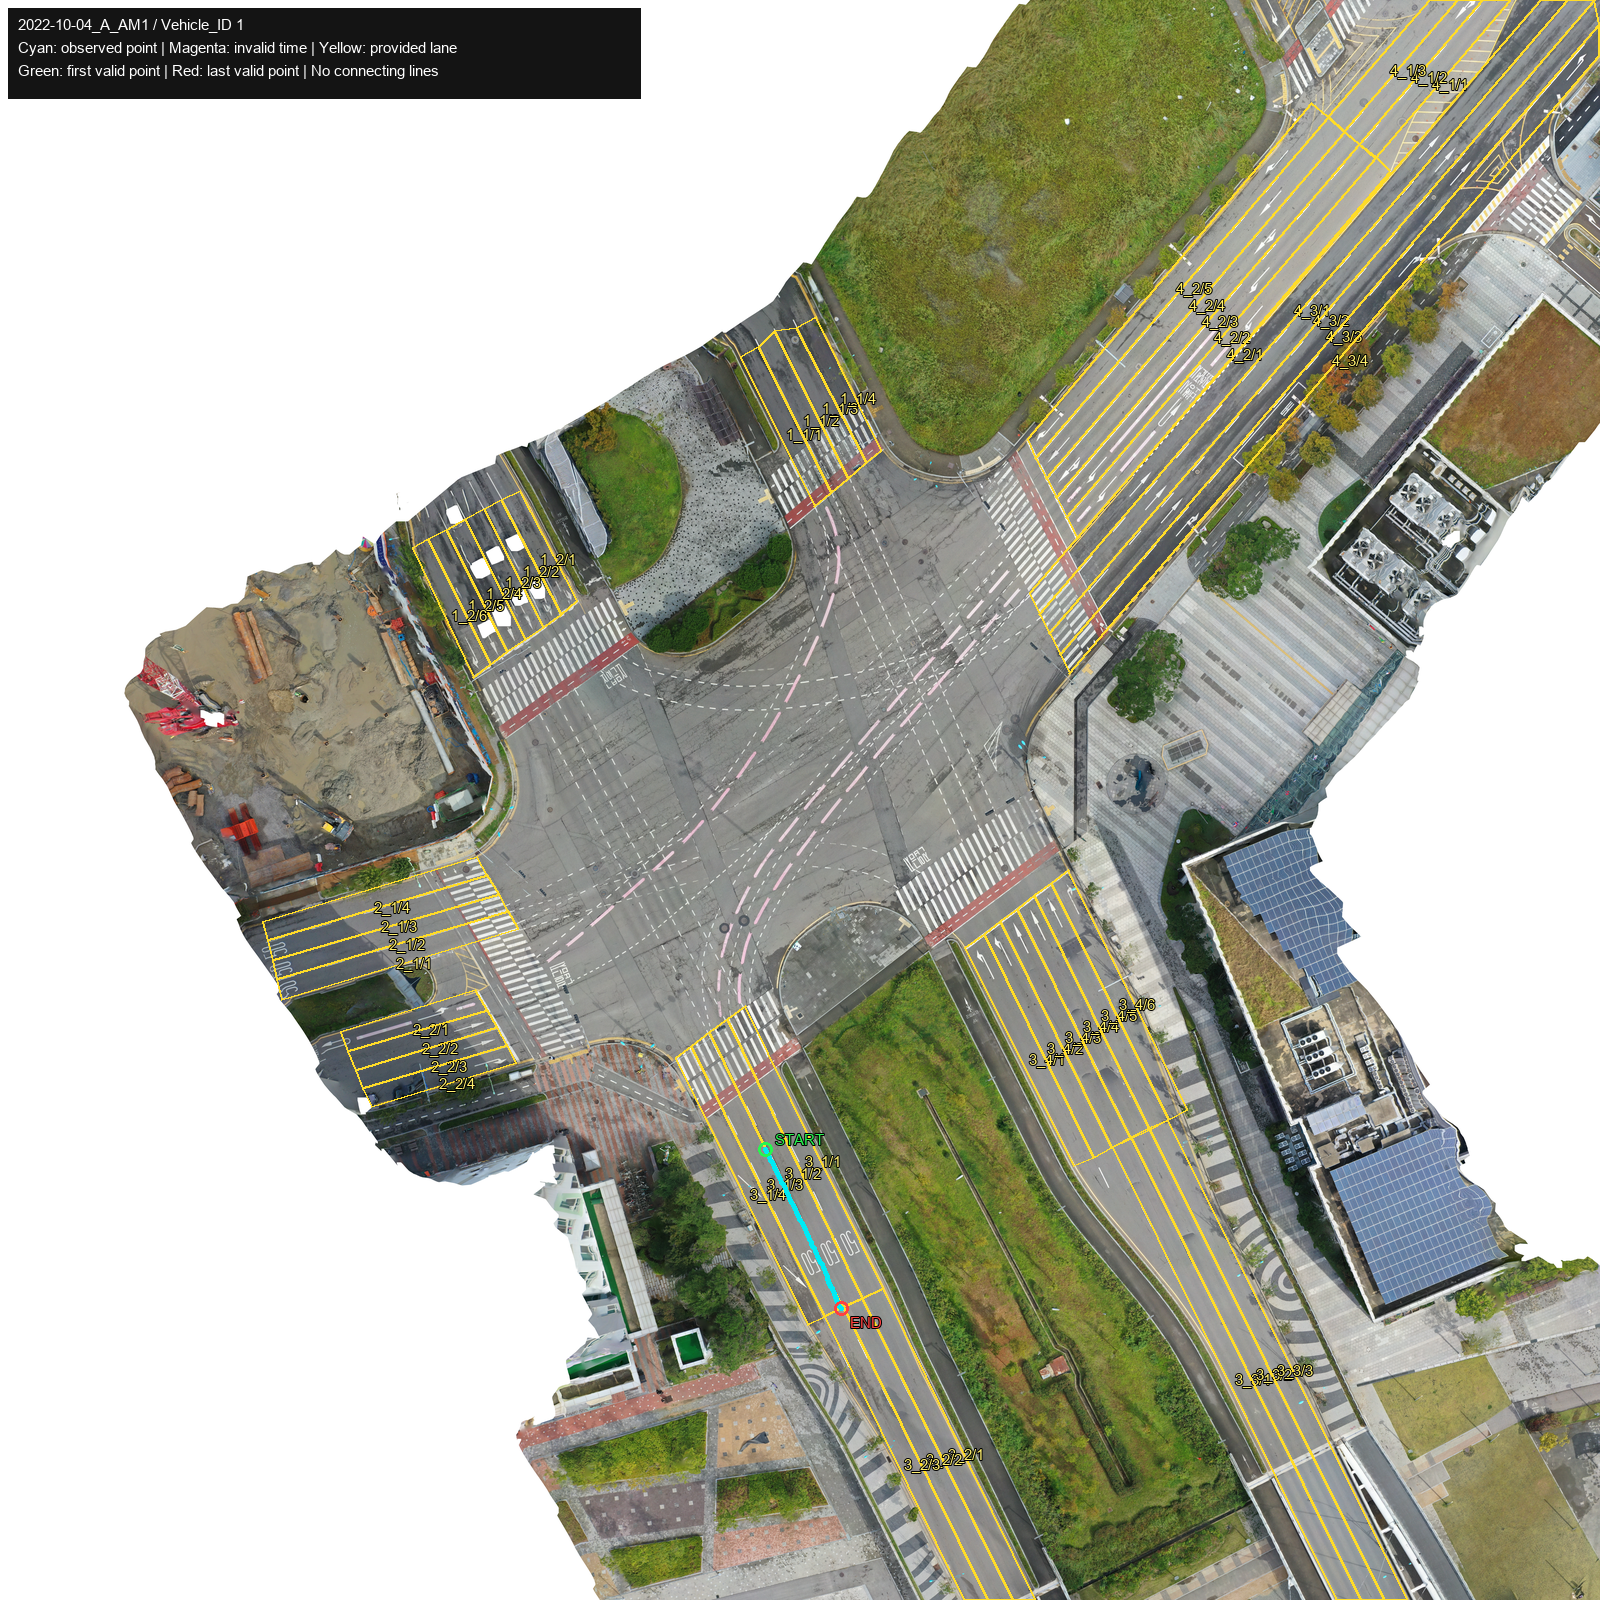

유효 영상 좌표 중 지도 바깥 행: 0
영상 좌표 오류 행: 0
이 그림만으로 회전 방향·상충·차량쌍을 확정하지 않습니다.


In [12]:
map_path = RAW / "orthophotos" / "orthophotos" / (selected_item["site"] + ".png")
lane_path = RAW / "segmentations" / "segmentations" / (selected_item["site"] + ".csv")
if not map_path.is_file() or not lane_path.is_file():
    raise FileNotFoundError("선택 지점의 정사영상 또는 차로 구역 파일이 없습니다.")

with Image.open(map_path) as original_map:
    original_width, original_height = original_map.size
    if (original_width, original_height) != (8000, 8000):
        raise ValueError("기대하는 8000×8000 지도와 크기가 다릅니다. 좌표 정의를 먼저 확인하세요.")
    shown_size = (1600, 1600)
    canvas = original_map.convert("RGB").resize(shown_size, Image.Resampling.LANCZOS)
scale_x, scale_y = shown_size[0] / original_width, shown_size[1] / original_height
drawing = ImageDraw.Draw(canvas)
font_path = Path("C:/Windows/Fonts/arial.ttf")
font = ImageFont.truetype(str(font_path), 15) if font_path.is_file() else ImageFont.load_default()

lanes = pd.read_csv(lane_path, dtype={"Section": "string", "Lane": "string"})
corners = [("tlx", "tly"), ("blx", "bly"), ("brx", "bry"), ("trx", "try")]
lane_coordinate_columns = [column for pair in corners for column in pair]
lane_numbers = lanes[lane_coordinate_columns].apply(pd.to_numeric, errors="coerce")
valid_lane_rows = np.isfinite(lane_numbers).all(axis=1)
if not valid_lane_rows.all():
    print("좌표를 해석할 수 없어 그리지 못한 차로 다각형:", int((~valid_lane_rows).sum()))
for row_index in lanes.index[valid_lane_rows]:
    polygon = [(float(lane_numbers.at[row_index, x]) * scale_x,
                float(lane_numbers.at[row_index, y]) * scale_y) for x, y in corners]
    drawing.line(polygon + [polygon[0]], fill=(255, 220, 40), width=2)
    center = (sum(x for x, y in polygon) / 4, sum(y for x, y in polygon) / 4)
    drawing.text(center, f"{lanes.at[row_index, 'Section']}/{lanes.at[row_index, 'Lane']}",
                 font=font, fill=(255, 240, 110), stroke_width=1, stroke_fill=(0, 0, 0))

within_map = (
    selected_points["_valid_ortho"]
    & selected_points["Ortho_X"].between(0, original_width, inclusive="left")
    & selected_points["Ortho_Y"].between(0, original_height, inclusive="left")
)
plot_points = selected_points.loc[within_map]  # 원본 행 순서로 점만 표시
for x, y, valid_time in plot_points[["Ortho_X", "Ortho_Y", "_valid_time"]].itertuples(index=False, name=None):
    px, py = float(x) * scale_x, float(y) * scale_y
    color = (0, 235, 245) if valid_time else (220, 70, 245)
    drawing.ellipse((px - 2, py - 2, px + 2, py + 2), fill=color)

time_ordered = selected_points.loc[selected_points["_valid_time"] & selected_points["_valid_ortho"]].sort_values(
    ["_time", "_source_row"], kind="stable"
)
if not time_ordered.empty:
    for label, row, color in [
        ("START", time_ordered.iloc[0], (40, 245, 80)),
        ("END", time_ordered.iloc[-1], (255, 65, 65)),
    ]:
        if 0 <= row["Ortho_X"] < original_width and 0 <= row["Ortho_Y"] < original_height:
            px, py = float(row["Ortho_X"]) * scale_x, float(row["Ortho_Y"]) * scale_y
            drawing.ellipse((px - 7, py - 7, px + 7, py + 7), outline=color, width=3)
            drawing.text((px + 9, py + (5 if label == "END" else -18)), label,
                         font=font, fill=color, stroke_width=1, stroke_fill=(0, 0, 0))
        else:
            print(label, "점은 지도 바깥에 있어 표시하지 않았습니다.")

drawing.rectangle((8, 8, 640, 98), fill=(20, 20, 20))
drawing.text((18, 16), f"{selected_stem} / Vehicle_ID {selected_vehicle}", font=font, fill="white")
drawing.text((18, 39), "Cyan: observed point | Magenta: invalid time | Yellow: provided lane", font=font, fill="white")
drawing.text((18, 62), "Green: first valid point | Red: last valid point | No connecting lines", font=font, fill="white")
display(canvas)
print("유효 영상 좌표 중 지도 바깥 행:", int((selected_points["_valid_ortho"] & ~within_map).sum()))
print("영상 좌표 오류 행:", int((~selected_points["_valid_ortho"]).sum()))
print("이 그림만으로 회전 방향·상충·차량쌍을 확정하지 않습니다.")


## 12. 다음 단계로 전달할 결과
이 셀의 출력과 지도 확인 결과를 저장한 노트북으로 함께 확인합니다. 다음 단계는 이 입력에 **출처가 확인된 기존 방법**을 적용하여 차량 간 관계와 TTC·PET 계산 절차를 구성하는 것입니다. 첫/끝 라벨만으로 회전 방향이나 상충유형을 자동 확정하지 않습니다.

결과 파일의 의미:
- `trajectories/*_trajectories.csv`: 원본 파일 + 차량별 요약. 날짜·세션·Drone_ID 출처·전체 라벨 순서·품질 상태 포함.
- `label_runs/*_label_runs.csv`: 같은 구역·차로 라벨이 시간순 관측행에서 이어진 구간. 시간 공백이 없다는 보장은 아님.
- `quality/*_quality_rows.csv`: 잘못된 ID·시각·좌표가 발견된 행. 원자료는 그대로 유지.
- `input_manifest.csv`, `progress.csv`, `run_metadata.json`: 대상과 처리 상태.
- `observed_label_sequences.csv`: 지점별 관측 라벨 순서에 해당하는 궤적 기록 수. 교통량·회전 교통량·상충 건수로 단정하지 않음.


In [13]:
current_metadata = json.loads((RUN_DIR / "run_metadata.json").read_text(encoding="utf-8"))
handoff = {
    "실행_ID": RUN_ID,
    "상태": current_metadata["status"],
    "전체_대상_파일": len(manifest),
    "완료_파일": int(current_metadata["completed_files"]),
    "오류_파일": int(current_metadata["failed_files"]),
    "완료파일_차량궤적기록수": int(totals.get("n_trajectories", 0)),
    "완료파일_관측행수": int(totals.get("n_source_rows", 0)),
    "완료파일_구역라벨미지정행": int(totals.get("n_missing_section_rows", 0)),
    "완료파일_차로라벨미지정행": int(totals.get("n_missing_lane_rows", 0)),
    "완료파일_ID오류행": int(totals.get("n_invalid_id_rows", 0)),
    "완료파일_시각오류행": int(totals.get("n_invalid_time_rows", 0)),
    "완료파일_위치좌표오류행": int(totals.get("n_invalid_local_rows", 0)),
    "결과폴더": str(RUN_DIR),
    "해석": "관측 궤적과 제공 라벨의 순서 정리. 아직 상충 건수·회전 방향·TTC/PET·EVT 결과가 아님.",
}
print(json.dumps(handoff, ensure_ascii=False, indent=2))
print("노트북을 저장한 뒤 이 출력과 지도에서 확인한 사항을 함께 검토합니다.")


{
  "실행_ID": "20260916T063821Z_28f9e8ee",
  "상태": "completed",
  "전체_대상_파일": 800,
  "완료_파일": 800,
  "오류_파일": 0,
  "완료파일_차량궤적기록수": 688840,
  "완료파일_관측행수": 776944506,
  "완료파일_구역라벨미지정행": 229854781,
  "완료파일_차로라벨미지정행": 229854781,
  "완료파일_ID오류행": 0,
  "완료파일_시각오류행": 0,
  "완료파일_위치좌표오류행": 0,
  "결과폴더": "C:\\Users\\123\\Documents\\(송도) 교통 연구 논문\\data\\processed\\songdo_movement\\20260916T063821Z_28f9e8ee",
  "해석": "관측 궤적과 제공 라벨의 순서 정리. 아직 상충 건수·회전 방향·TTC/PET·EVT 결과가 아님."
}
노트북을 저장한 뒤 이 출력과 지도에서 확인한 사항을 함께 검토합니다.
